In [1]:
import glob
import io
import sys
from pyhere import here

import anndata
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import matplotlib

import seaborn as sns
from scipy.stats import chi2_contingency

import scib

# My modules / functions
sys.path.append(str(here('scripts/misc')))  
import my_anndata as ma

## Set up parameters

In [2]:
# Plotting
plt.style.use('default') 

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
 
SMALL_SIZE = 4
MEDIUM_SIZE = 6
BIGGER_SIZE = 8
 
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

sc.set_figure_params(figsize=(2, 2), frameon=False, dpi_save= 300)

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/matplotlib_inline/config.py:54: DeprecationWarning: InlineBackend._print_figure_kwargs_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _update_figure_formatters(self):


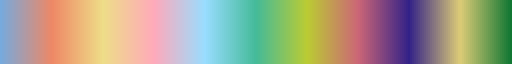

In [22]:
# Color bar
import tol_colors
import matplotlib.colors as mcolors

# Get the list of colors from each palette
light_colors = tol_colors.light[:7] # remove overlapping colors
bright_colors = tol_colors.muted[:4] # remove overlapping colors

# Combine the two lists of colors
combined_colors = light_colors + bright_colors

# Now, use this longer list to create a colormap or pass it directly to Scanpy
combined_cmap = mcolors.LinearSegmentedColormap.from_list(
    'combined_tol', combined_colors
)
combined_cmap

In [3]:
# Directories
ma.create_directories(dir_path = str(here('data/integrate/files')))

/work/islet_cartography_scrna/data/integrate/files Directory already exists!


## Define technical covariates

In [3]:
covariates = ['ic_id_donor_overall', 
                  'ic_id_study_overall',
                  'library_prep', 
                  'strandedness', 
                 'cell_nuclei',
                 'count_quantification', 
                  'count_molecule',
                 'treatment_facs',
                 'islet_allocation_facility',
                  'cold_ischemia_hours',
                  'sequencing_run',
                  'dissociation_method',
                  'islet_fresh_frozen',
                  'dissociation_tool',
                  'islet_culture_medium']

## Load

In [4]:
adata = sc.read_h5ad(here('data/anndata/AB_combined.h5ad'))

## Which covariate has missing values

In [5]:
df = []
for cov in covariates:
    n_missing = adata.obs[cov].isna().sum()
    pct_missing = n_missing / adata.n_obs * 100
    df.append(
    {
        'covariate': cov,
        'n_missing': n_missing,
        'pct_missing':  pct_missing
    }
)
df = pd.DataFrame(df)

In [6]:
covariates = df['covariate'].tolist()
new_covariates = []
for cov in covariates:
    row = df[df['covariate'] == cov].iloc[0]
    if row['pct_missing'] == 0:
        new_covariates.append(cov)
    else:
        print(f"Skipped {cov} ({row['pct_missing']*100:.2f}% missing) because too many missing values")

Skipped treatment_facs (9664.85% missing) because too many missing values
Skipped islet_allocation_facility (5926.30% missing) because too many missing values
Skipped cold_ischemia_hours (8164.81% missing) because too many missing values
Skipped sequencing_run (9933.83% missing) because too many missing values
Skipped dissociation_method (2892.27% missing) because too many missing values
Skipped islet_fresh_frozen (8355.17% missing) because too many missing values
Skipped dissociation_tool (2892.27% missing) because too many missing values
Skipped islet_culture_medium (3368.51% missing) because too many missing values


## PC Regression

In [7]:
# Run pca 
sc.tl.pca(
    adata,
    n_comps=20,       
    svd_solver='arpack',
    use_highly_variable=False,
    copy=False              # modifies adata in place
)

pcr_results = {}

for cov in new_covariates:
    print(f'Regression for {cov}')
    r2 = scib.metrics.pcr(
        adata,
        covariate=cov,
        n_comps=20,
        recompute_pca=False,
        verbose=False,
        n_threads=60
    )
    pcr_results[cov] = r2

/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


Regression for ic_id_donor_overall
Regression for ic_id_study_overall
Regression for library_prep
Regression for strandedness
Regression for cell_nuclei
Regression for count_quantification
Regression for count_molecule


In [8]:
# Run PCA (modifies adata in place)
sc.tl.pca(
    adata,
    n_comps=20,
    svd_solver='arpack',
    use_highly_variable=False,
    copy=False
)

# Compute observed R² for each covariate
observed_r2 = {}
for cov in new_covariates:
    print(f'Observed regression for {cov}')
    r2 = scib.metrics.pcr(
        adata,
        covariate=cov,
        n_comps=20,
        recompute_pca=False,
        verbose=False,
        n_threads=60
    )
    observed_r2[cov] = r2
    
# Permutation test
n_permutations = 10000
permutation_r2 = {cov: [] for cov in new_covariates}

for cov in new_covariates:
    print(f'Running permutation test for {cov}')
    for i in range(n_permutations):
        # Shuffle covariate labels for the current variable
        adata.obs['shuffled'] = np.random.permutation(adata.obs[cov].values)
        r2 = scib.metrics.pcr(
            adata,
            covariate='shuffled',
            n_comps=20,
            recompute_pca=False,
            verbose=False,
            n_threads=60
        )
        permutation_r2[cov].append(r2)

# Compute empirical p-values with +1 correction
p_values = {}
for cov in new_covariates:
    count = np.sum(np.array(permutation_r2[cov]) >= observed_r2[cov])
    p_values[cov] = (count + 1) / (n_permutations + 1)

print("Empirical p-values with +1 correction:", p_values)

/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


Observed regression for ic_id_donor_overall
Observed regression for ic_id_study_overall
Observed regression for library_prep
Observed regression for strandedness
Observed regression for cell_nuclei
Observed regression for count_quantification
Observed regression for count_molecule
Running permutation test for ic_id_donor_overall
Running permutation test for ic_id_study_overall
Running permutation test for library_prep
Running permutation test for strandedness
Running permutation test for cell_nuclei
Running permutation test for count_quantification
Running permutation test for count_molecule
Empirical p-values with +1 correction: {'ic_id_donor_overall': np.float64(9.999000099990002e-05), 'ic_id_study_overall': np.float64(9.999000099990002e-05), 'library_prep': np.float64(9.999000099990002e-05), 'strandedness': np.float64(9.999000099990002e-05), 'cell_nuclei': np.float64(9.999000099990002e-05), 'count_quantification': np.float64(9.999000099990002e-05), 'count_molecule': np.float64(9.999

In [10]:
import pickle
import os
with open(os.path.join(here('data/integrate/files'), 'pcr_permutation_permuted_r2.pkl'), 'wb') as f:
    pickle.dump(permutation_r2, f)

In [14]:
# Create a DataFrame from the results
results_df = pd.DataFrame({
    'covariate': list(observed_r2.keys()),
    'observed_r2': list(observed_r2.values()),
    'empirical_p': [p_values[cov] for cov in observed_r2.keys()]
})

# Optional: set covariate as index
results_df.set_index('covariate', inplace=True)

# Save to CSV
results_df.to_csv('pcr_permutation_results.csv')

# View the dataframe
print(results_df)

                      observed_r2  empirical_p
covariate                                     
ic_id_donor_overall      0.708818       0.0001
ic_id_study_overall      0.647675       0.0001
library_prep             0.617058       0.0001
strandedness             0.007251       0.0001
cell_nuclei              0.511097       0.0001
count_quantification     0.025234       0.0001
count_molecule           0.016522       0.0001


In [ ]:
results_df.to_csv(here('data/integrate/files/pcr_permutation_results.csv'))

## Print results and save

In [ ]:
pd.DataFrame.from_dict(pcr_results, orient='index', columns=['r_squared']).sort_values('r_squared', ascending=False)

/tmp/ipykernel_1071/2521186581.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


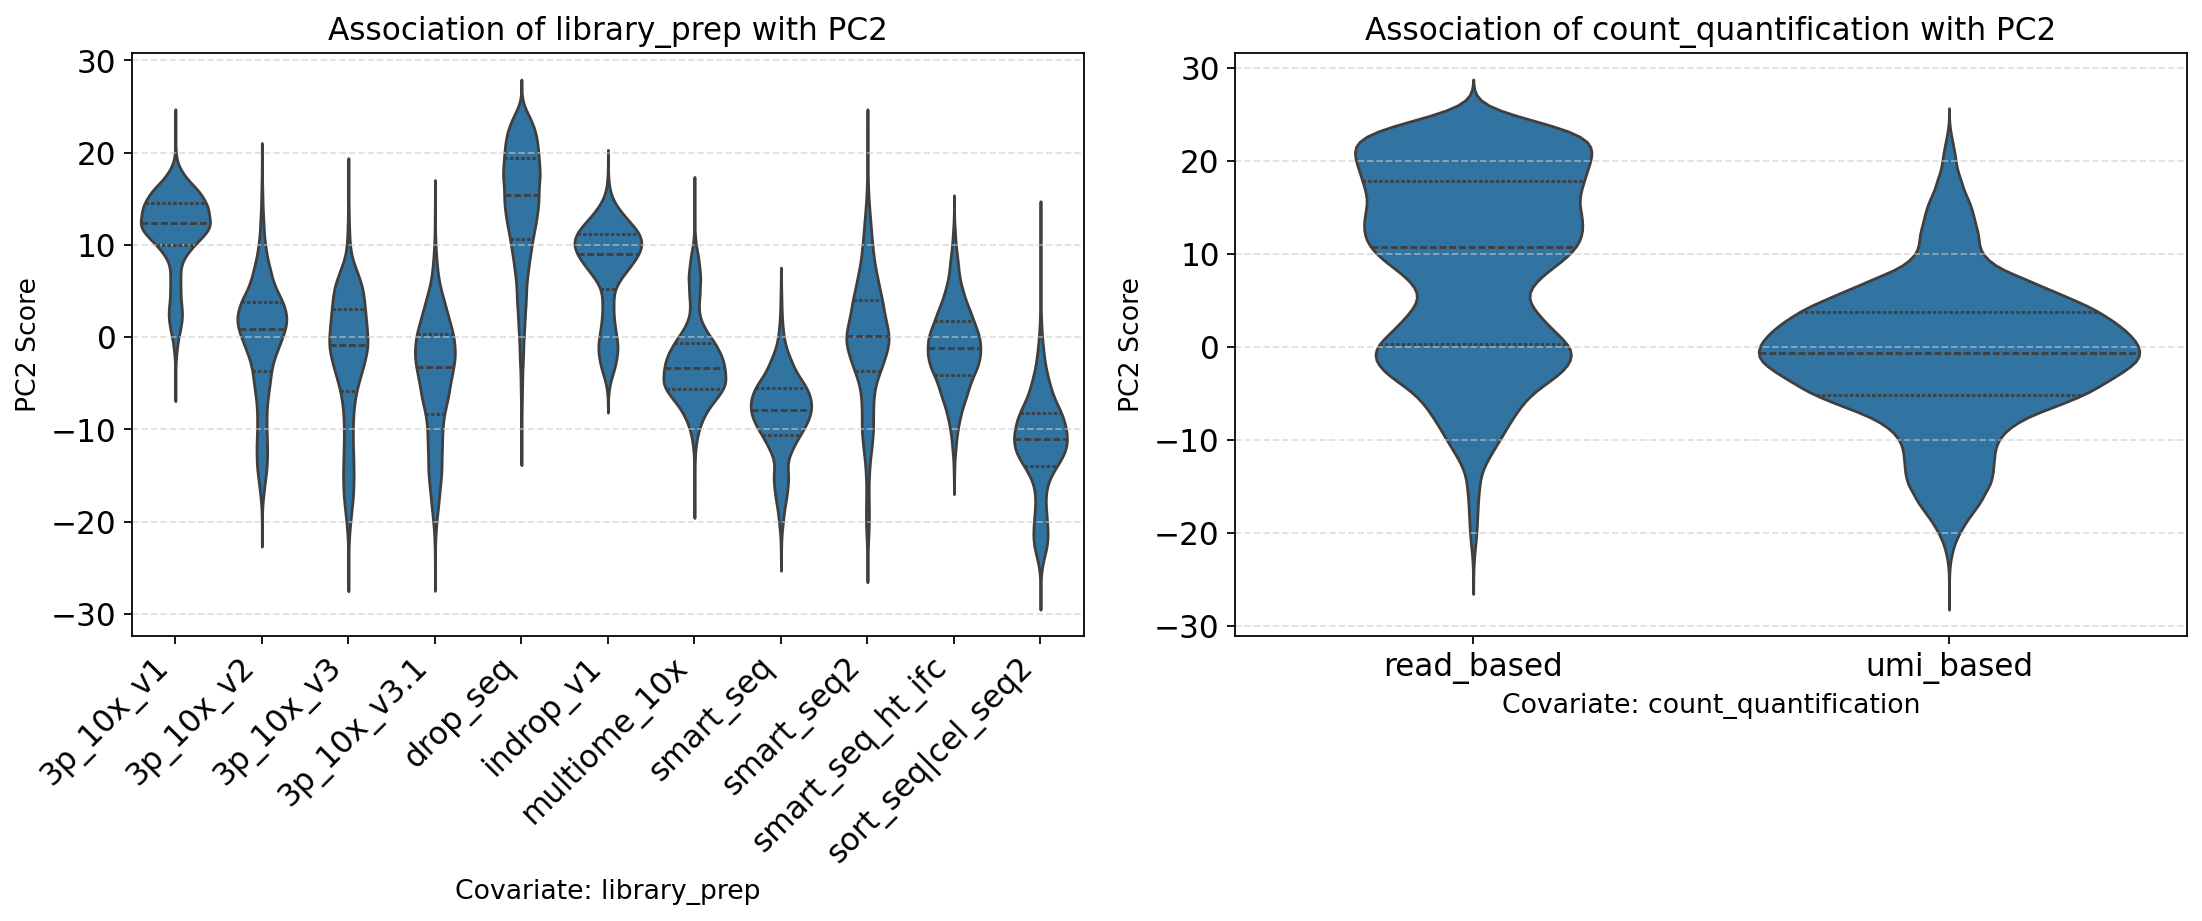

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Configuration: CHANGE THESE VALUES ---
# Assume 'adata' is your AnnData object loaded into the environment
# Example: adata = sc.read_h5ad('my_data.h5ad')

# 1. Define the PC to plot (PC1 is usually index 0, PC2 is index 1, etc.)
PC_INDEX = 1 
PC_NAME = f'PC{PC_INDEX + 1}' 

# 2. Define your High R2 and Low R2 Covariates
HIGH_R2_COV = 'library_prep'    # Example of a covariate expected to have high R2
LOW_R2_COV = 'count_quantification'          # Example of a covariate expected to have low R2

# ----------------------------------------------------------------------

# 1. Extract the PC Scores from adata
pc_scores = adata.obsm['X_pca'][:, PC_INDEX]

# 2. Prepare Data for Plotting
# Create a temporary DataFrame to combine PC scores and covariates
plot_data = adata.obs[[HIGH_R2_COV, LOW_R2_COV]].copy()
plot_data[PC_NAME + '_Score'] = pc_scores

# 3. Create the Visualization (Box Plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: High R2 Covariate ---
sns.violinplot(
    ax=axes[0],
    data=plot_data,
    x=HIGH_R2_COV,
    y=PC_NAME + '_Score',
    inner='quartile'
)
axes[0].set_title(f'Association of {HIGH_R2_COV} with {PC_NAME}', fontsize=14)
axes[0].set_xlabel(f'Covariate: {HIGH_R2_COV}', fontsize=12)
axes[0].set_ylabel(f'{PC_NAME} Score', fontsize=12)
#axes[0].tick_params(axis='x', rotation=45) 
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# --- Plot 2: Low R2 Covariate ---
sns.violinplot(
    ax=axes[1],
    data=plot_data,
    x=LOW_R2_COV,
    y=PC_NAME + '_Score',
    inner='quartile'
)
axes[1].set_title(f'Association of {LOW_R2_COV} with {PC_NAME}', fontsize=14)
axes[1].set_xlabel(f'Covariate: {LOW_R2_COV}', fontsize=12)
axes[1].set_ylabel(f'{PC_NAME} Score', fontsize=12) # Retain Y-axis label for comparison
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show() # Use plt.savefig('my_pcr_plots.png') to save the image.

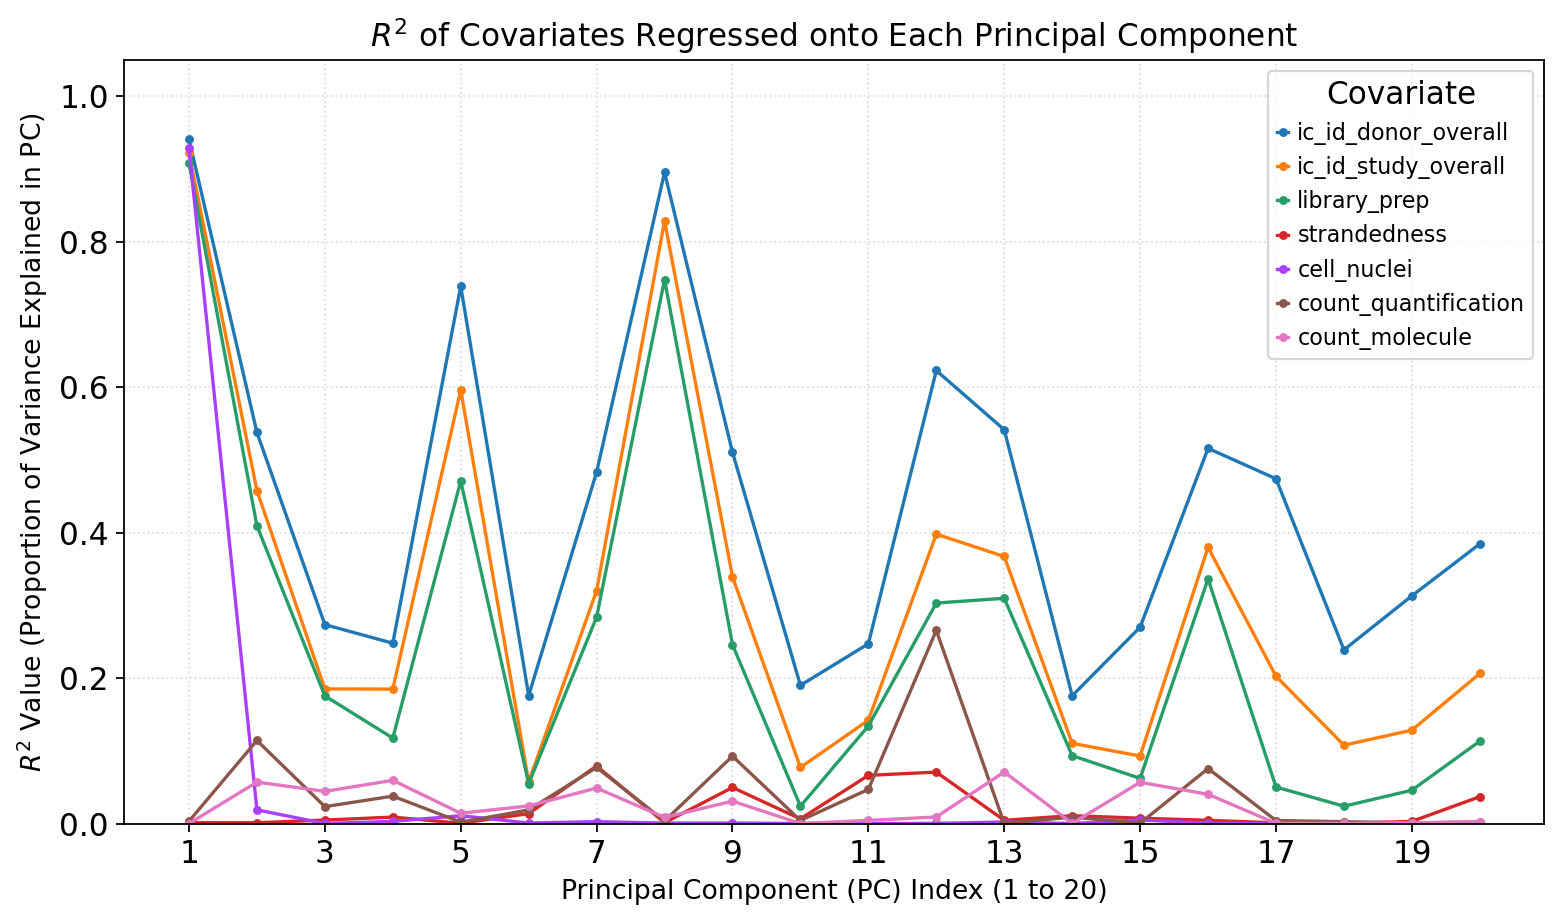

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Configuration: CHANGE THESE VALUES ---
# Define which covariates you want to plot (e.g., your two high-signal covariates)
COVARIATES_TO_PLOT = new_covariates # REPLACE with your actual covariate names
n_pcs_to_plot = 20 # Must match the n_comps used in sc.tl.pca

# Assuming 'adata' (your AnnData object) is loaded in your environment
# ----------------------------------------------------------------------

# --- Function to Calculate R2 for EACH PC ---
def calculate_r2_per_pc(adata, covariate_name, n_comps):
    """Calculates R2 for the regression of PC_i onto the covariate."""
    
    pc_scores = adata.obsm['X_pca'][:, :n_comps]
    B_series = adata.obs[covariate_name]
    
    # Handle categorical covariates: One-hot encode
    if B_series.dtype.name in ['category', 'object']:
        # Use one-hot encoding for multi-categorical variables
        B = pd.get_dummies(B_series, drop_first=True).values
    else:
        # Continuous or Binary Covariate
        B = B_series.values.reshape(-1, 1)

    r2_per_pc = []
    regression_model = LinearRegression()

    for i in range(n_comps):
        PC_i = pc_scores[:, i].reshape(-1, 1)
        
        # Check for non-varying data
        if np.std(PC_i) == 0 or np.linalg.matrix_rank(B) < B.shape[1]:
            r2_i = 0.0
        else:
            regression_model.fit(B, PC_i)
            PC_i_predicted = regression_model.predict(B)
            r2_i = r2_score(PC_i, PC_i_predicted)
        
        r2_per_pc.append(r2_i)
        
    return np.array(r2_per_pc)

# --- Main Plotting Loop ---
plt.figure(figsize=(10, 6))
pc_indices = np.arange(1, n_pcs_to_plot + 1)

for k, cov in enumerate(COVARIATES_TO_PLOT):
    # Calculate the R2 for each PC using your AnnData
    r2_per_pc = calculate_r2_per_pc(adata, cov, n_pcs_to_plot)
    
    plt.plot(
        pc_indices, 
        r2_per_pc, 
        marker='.', 
        linestyle='-', 
        label=f'{cov}'
    )

plt.title('$R^2$ of Covariates Regressed onto Each Principal Component', fontsize=14)
plt.xlabel(f'Principal Component (PC) Index (1 to {n_pcs_to_plot})', fontsize=12)
plt.ylabel('$R^2$ Value (Proportion of Variance Explained in PC)', fontsize=12)
plt.xticks(pc_indices[::2])
plt.ylim(0.0, 1.05)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Covariate', fontsize=10)
plt.tight_layout()
plt.show() 
# You can use plt.savefig('r2_per_pc_summary.png') to save the image.

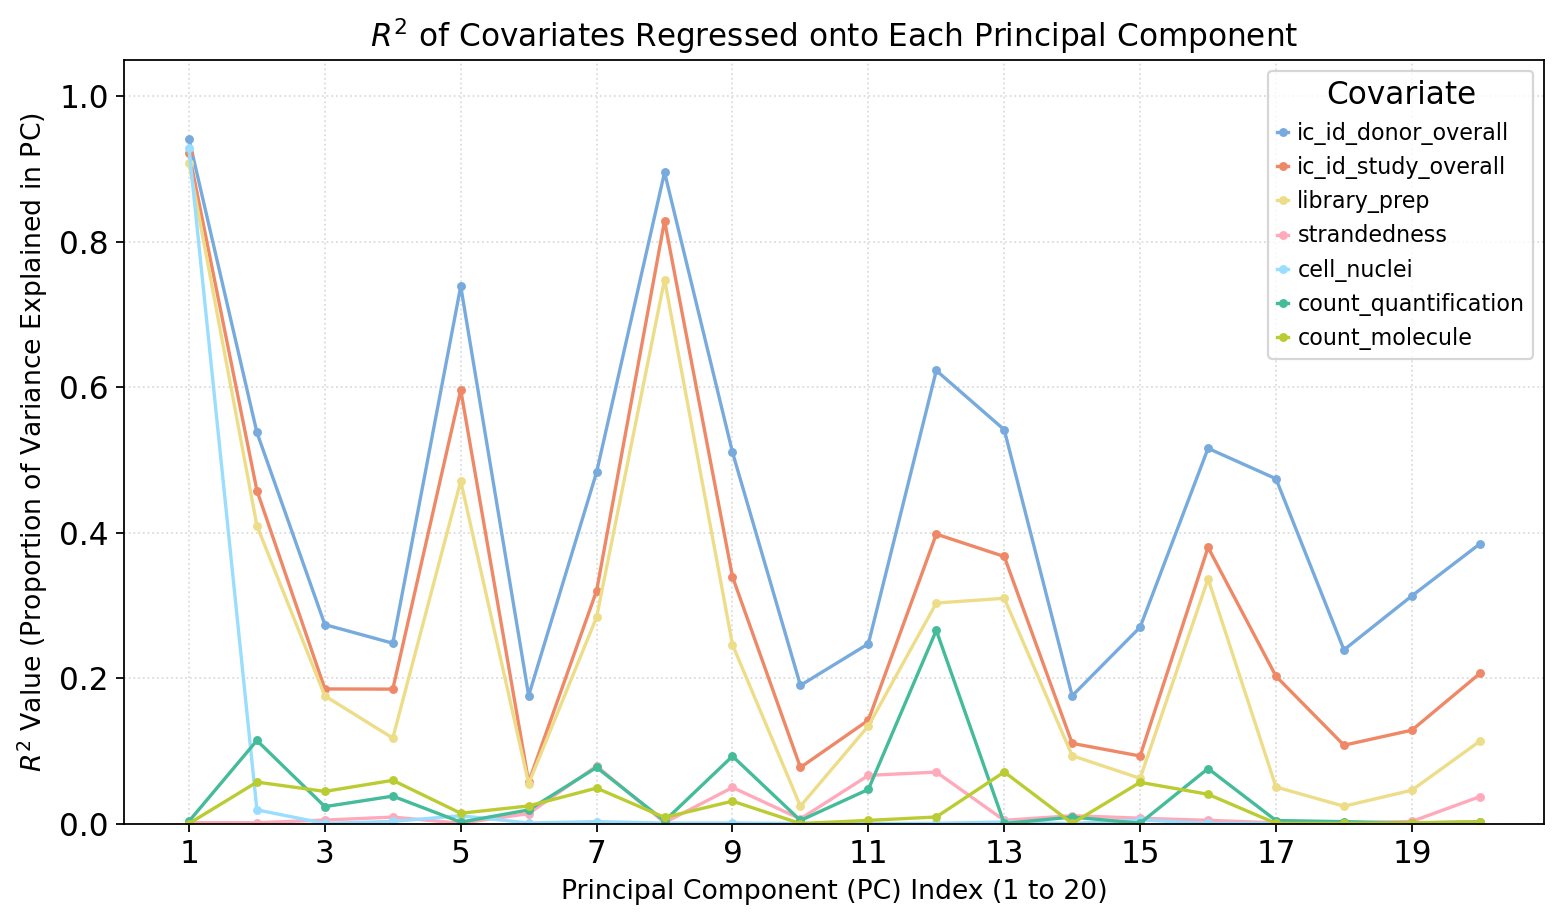

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# Assuming tol_colors and mcolors imports are handled and combined_cmap is defined

# --- Main Plotting Loop (Modified to use the palette dictionary) ---
plt.figure(figsize=(10, 6))
pc_indices = np.arange(1, n_pcs_to_plot + 1)

# Ensure the new_covariates list matches the keys used in your palette definition
# If you only defined the palette for ONE covariate (col), you should only plot that one.
# For simplicity, we assume your 'new_covariates' list contains the covariate 'col'
# that you used to build the palette.

# Note: The code snippet you provided for the palette is typically used for UMAP/scatter plots,
# not for line plots comparing different covariates. For this R2 plot, you want
# to color *each covariate line* differently, not the categories within one covariate.
#
# If you have a small, fixed list of covariates (e.g., 3-5), we can assign colors manually
# from your combined_colors list.

# --- Corrected Approach for Coloring Covariate LINES ---
# If you want to use the N colors for the N lines (covariates):
if len(COVARIATES_TO_PLOT) > len(combined_colors):
    print("Warning: More covariates than defined colors. Colors will recycle.")

for k, cov in enumerate(COVARIATES_TO_PLOT):
    # Get the color for this specific covariate line from your list
    line_color = combined_colors[k % len(combined_colors)]
    
    # Calculate the R2 for each PC using your AnnData
    r2_per_pc = calculate_r2_per_pc(adata, cov, n_pcs_to_plot)
    
    plt.plot(
        pc_indices, 
        r2_per_pc, 
        marker='.', 
        linestyle='-', 
        color=line_color,  # <-- Use the specific color
        label=f'{cov}'
    )

plt.title('$R^2$ of Covariates Regressed onto Each Principal Component', fontsize=14)
plt.xlabel(f'Principal Component (PC) Index (1 to {n_pcs_to_plot})', fontsize=12)
plt.ylabel('$R^2$ Value (Proportion of Variance Explained in PC)', fontsize=12)
plt.xticks(pc_indices[::2])
plt.ylim(0.0, 1.05)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Covariate', fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1071/361547354.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1071/361547354.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


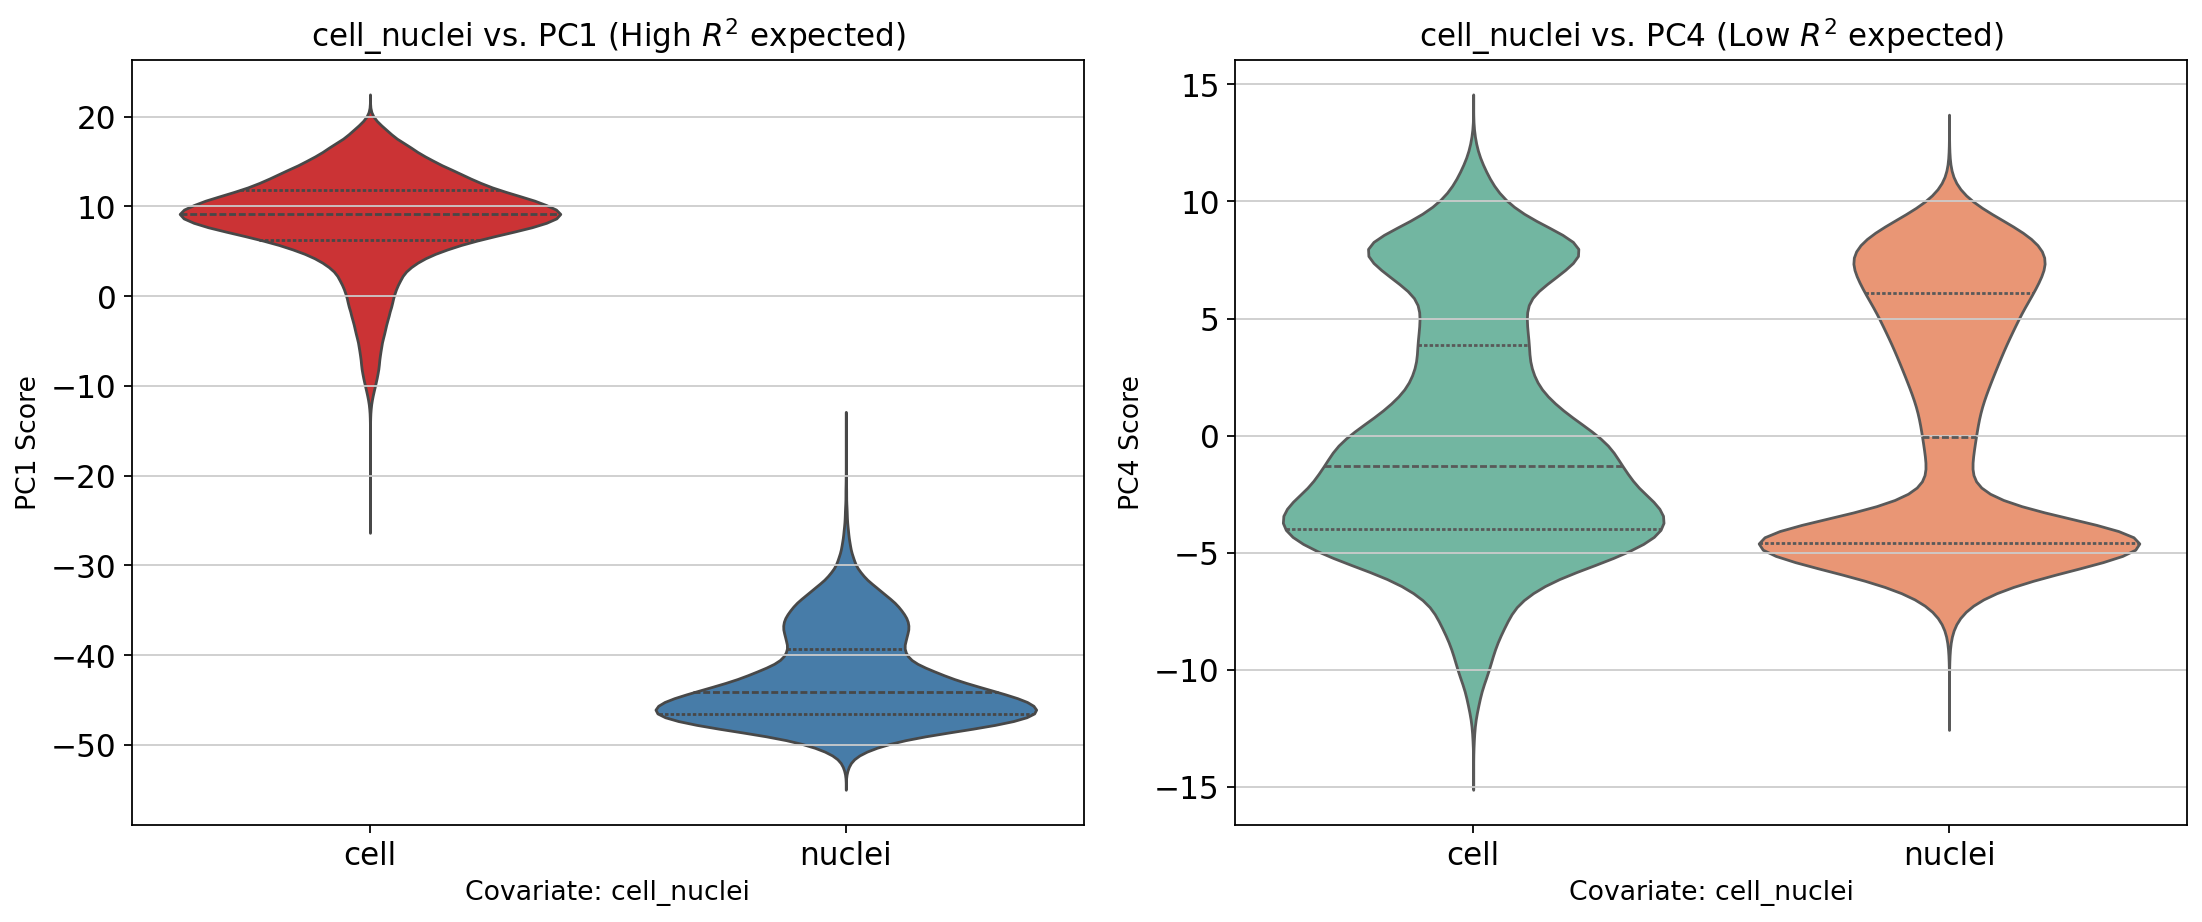

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Configuration: CHANGE ONLY THE COVARIATE NAME ---
# Define the covariate that showed a strong signal (e.g., 'batch_id' or 'cell_type')
HIGH_SIGNAL_COV = 'cell_nuclei' # <-- REPLACE with the name of your target covariate

# Define the PCs to plot: PC1 (High R2) and a later PC (Low R2)
PC_HIGH_R2_INDEX = 0 # PC1
PC_LOW_R2_INDEX = 3  # PC4 (index 3). Feel free to try index 4 (PC5) or 5 (PC6) if PC4 is still high.
# Assuming 'adata' (your AnnData object) is loaded in your environment
# ----------------------------------------------------------------------

# 1. Extract the PC Scores from adata
pc_scores = adata.obsm['X_pca']

# 2. Prepare Data for Plotting
plot_data = adata.obs[[HIGH_SIGNAL_COV]].copy()

# Add scores for both PCs
PC1_NAME = f'PC{PC_HIGH_R2_INDEX + 1}'
PC4_NAME = f'PC{PC_LOW_R2_INDEX + 1}'

plot_data[PC1_NAME + '_Score'] = pc_scores[:, PC_HIGH_R2_INDEX]
plot_data[PC4_NAME + '_Score'] = pc_scores[:, PC_LOW_R2_INDEX]

# 3. Create the Visualization (Violin Plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: High R2 Association (PC1) ---
sns.violinplot(
    ax=axes[0],
    data=plot_data,
    x=HIGH_SIGNAL_COV,
    y=PC1_NAME + '_Score',
    inner='quartile', 
    palette='Set1'
)
axes[0].set_title(f'{HIGH_SIGNAL_COV} vs. {PC1_NAME} (High $R^2$ expected)', fontsize=14)
axes[0].set_xlabel(f'Covariate: {HIGH_SIGNAL_COV}', fontsize=12)
axes[0].set_ylabel(f'{PC1_NAME} Score', fontsize=12)

# --- Plot 2: Low R2 Association (PC4) ---
sns.violinplot(
    ax=axes[1],
    data=plot_data,
    x=HIGH_SIGNAL_COV,
    y=PC4_NAME + '_Score',
    inner='quartile',
    palette='Set2'
)
axes[1].set_title(f'{HIGH_SIGNAL_COV} vs. {PC4_NAME} (Low $R^2$ expected)', fontsize=14)
axes[1].set_xlabel(f'Covariate: {HIGH_SIGNAL_COV}', fontsize=12)
axes[1].set_ylabel(f'{PC4_NAME} Score', fontsize=12)

plt.tight_layout()
plt.show()